In [54]:
import numpy as np
from os import listdir, makedirs
import matplotlib.pyplot as plt
from datetime import datetime

import torch
import torch.onnx
from torch import nn
import torch.nn.functional as F
import torch.optim as optim

from tqdm.notebook import tqdm

#torch.cuda.is_available()
#torch.cuda.device_count()
#torch.cuda.current_device()
#torch.cuda.get_device_name(0)
torch.use_deterministic_algorithms(True)

## Setup

In [55]:
def build_network(layer_number = "3", layer_conv = "None", layer_type = "Linear", activation_type = "ReLU", half=False):
    """
    # build_network

    build_network(layer_number = "3", layer_conv = None, layer_type = "Linear", activation_type = "ReLU", half=False)

    Build neural network with desired caracteristics. 

    - layer_number ("3","5","7","9" or "11") : Number of hidden layer in the bowtie network.
    - layer_conv ("None", "Conv1d") : Convolution layer in the input and output layer.
    - layer_type ("Linear") : Type of layer used.
    - activation_type ("ReLU", "Sigmoid", "CELU", "Softmax", "Softmin", "Hardshrink"), "LeakyReLU") : Type of activation function for the entire network.
    - half (True, False) : If True, only half the network is assembled, creating a triangular network with one output.
    """
    startEnd = 496

    # Layer type
    layer_type_dict = {
        "Linear" : nn.Linear
    }
    layer = layer_type_dict[layer_type]

    # Activation function
    activation_dict = {
        "ReLU"       : nn.ReLU,
        "Sigmoid"    : nn.Sigmoid,
        "CELU"       : nn.CELU, 
        "Softmax"    : nn.Softmax,
        "Softmin"    : nn.Softmin,
        "Hardshrink" : nn.Hardshrink,
        "LeakyReLU"  : nn.LeakyReLU
    }
    activation = activation_dict[activation_type]

    # Number of layer
    layer_number_dict = {
        "3"  : [startEnd,248,1,248,startEnd],
        "5"  : [startEnd,330,165,1,165,330,startEnd],
        "7"  : [startEnd,372,248,124,1,124,248,372,startEnd],
        "9"  : [startEnd,400,300,200,100,1,100,200,300,400,startEnd],
        "11" : [startEnd,411,329,247,165,82,1,82,165,247,329,411,startEnd]
    }
    layer_list = layer_number_dict[layer_number]

    if half:
        layer_list = layer_list[:len(layer_list) // 2 + 1]

    # Build network
    network = nn.Sequential()

    if layer_conv == "Conv1d":
        network.append(nn.Conv1d(1, 1,kernel_size=3,stride=1,padding=1))

    for index, layer_pos in enumerate(layer_list[:-2]):
        network.append(layer(layer_list[index], layer_list[index+1]))
        network.append(activation())

    network.append(layer(layer_list[-2], layer_list[-1]))

    if layer_conv == "Conv1d" and not half:
        network.append(nn.Conv1d(1, 1,kernel_size=3,stride=1,padding=1))

    return network

In [56]:
def build_dataset(batch_size ,path):
    """
    # build_dataset

    build_dataset(batch_size ,path)

    - batch_size (int) : Selects N first elements of the dataset
    - path (str) : Path to the dataset. 
    """
    TES = np.concatenate([np.fromfile(f"{path}{fileName}",dtype=np.uint16).reshape(-1,496) for fileName in listdir(path)])
    normTES = (TES - np.min(TES)) / (np.max(TES) - np.min(TES))

    # Train model to reproduce identity operation
    loader = torch.tensor(normTES[:batch_size],dtype=torch.float32).view(-1,1,496)

    return loader

In [57]:
def build_optimizer(network, learning_rate, optimizer_type="adam"):
    """
    # build_optimizer

    build_optimizer(network, learning_rate, optimizer_name="adam")

    - network (Pytorch Sequential) : Bowtie neural network that is trained to reproduce its input signal.
    - learning_rate (float) : Learning rate used in the optimizer.
    - optimizer_type ("sgd", "adam") : Type of optimizer used in the training process.
    """
    if optimizer_type == "sgd":
        optimizer = optim.SGD(network.parameters(), lr=learning_rate, momentum=0.9)
    elif optimizer_type == "adam":
        optimizer = optim.Adam(network.parameters(), lr=learning_rate)
    
    return optimizer

In [58]:
def build_criterion(criterion_type="CrossEntropy"):
    """
    # build_criterion

    build_criterion(criterion_name="CrossEntropy")

    - criterion_type ("CrossEntropy", "L1Loss") : Type ocriterion used in the training process.
    """
    criterion_dict = {
        "CrossEntropy" : nn.CrossEntropyLoss(),
        "L1Loss" : nn.L1Loss()
    }
    
    return criterion_dict[criterion_type]

In [59]:
def save_object(save_object, file_name):
    """
    # save_object

    save_object(save_object, file_name)

    
    """
    try:
        np.save(f'{file_name}', arr=save_object, allow_pickle=True)
    except Exception as ex:
        print("Error during saving process : ", ex)

In [60]:
def train_epoch(network, loader, optimizer, criterion, batch_size):
    """
    # train_epoch

    train_epoch(network, loader, optimizer, criterion, batch_size)

    Training process executed for every epoch. The actions consists of setting the gradients to zero, 
    making predictions for the batch, computing the loss and its gradientand updating the weights and biases.

    - network (Pytorch Sequential) : Bowtie neural network that is trained to reproduce its input signal.
    - loader (Pytorch tensor) :  Dataset
    - optimizer (Pytorch optimizer) : Optimizer used for training.
    - criterion(Pytorch optimizer) : Criterion used for training.
    - batch_size (int) : Size of the dataset.
    """
    cumu_loss = 0
    batch_loss = np.zeros(batch_size)

    for index, data in enumerate(loader):
        optimizer.zero_grad()
        
        # Forward
        loss = criterion(network(data), data)
        cumu_loss += loss.item()

        # Backward
        loss.backward()
        optimizer.step()

        batch_loss[index] = loss.item()

    return cumu_loss / len(loader), batch_loss , network

In [61]:
def test(network, network_half, loader):
    """
    # test

    test(network, network_half, loader)

    From a trained bowtie network, a triangular network is created to associate input signals to singular values.
    This way, the triangular network acts as a dimensionality reduction technique.
    
    - network (Pytorch Sequential) : Trained bowtie neural network.
    - network_half (Pytorch Sequential) : Untrained triangular neural network.
    - loader (Pytorch tensor) :  Dataset
    """
    state_dict = network.state_dict()
    state_dict_copy = state_dict.copy()
    
    lenght = len(state_dict)/2
    for index, element in enumerate(state_dict_copy):
        if index >= lenght:
            del state_dict[f"{element}"]

    network_half.load_state_dict(state_dict)
    output = network_half(loader).detach().numpy()

    return output

In [62]:
def train(config):
    """
    # train

    train(config)

    Execute a neural network experiment by creating a bowtie neural network and training it to reproduce the it's input signal.
    Once it is trained, half the network is used to associate each signal to a singular value. 
    This way, the network acts as a dimensionality reduction technique.

    - config (dict) : Dictionary with the configuration parameters
        example :

        config = {
            'path_data' : 'dataset/',
            'path_save' : 'neural network/',
            'layer_number': '7',
            'layer_type': 'Linear',
            'layer_conv': 'None',
            'activation_type': 'Sigmoid',
            'batch_size': 5000,
            'optimizer': 'adam',
            'epochs': 5,
            'learning_rate': 0.001,
            }
    """
    file_name = datetime.now().strftime("%Y-%m-%d-%H-%M")
    makedirs(f"{config['path_save']}{file_name}")
    epoch_loss_list = np.zeros(config['epochs'])
    batch_loss_list = np.zeros(config['epochs'])

    loader = build_dataset(config['batch_size'],config['path_data'])
    network = build_network(config['layer_number'], config['layer_conv'], config['layer_type'], config['activation_type'])
    optimizer = build_optimizer(network, config['learning_rate'], config['optimizer'])
    criterion = build_criterion("CrossEntropy")

    for epoch in tqdm(range(config['epochs']), position=0):
        epoch_loss, batch_loss, network = train_epoch(network, loader, optimizer, criterion, config['batch_size'])
    
        batch_loss_list = np.concatenate((batch_loss_list, batch_loss))
        epoch_loss_list[epoch] = float(epoch_loss)
        
    network_half = build_network(config['layer_number'], config['layer_conv'], config['layer_type'], config['activation_type'], half=True)
    results = test(network, network_half, loader)

    torch.save(network.state_dict() , f"{config['path_save']}{file_name}/model.pt")
    save_object(results , f"{config['path_save']}{file_name}/results")
    save_object(epoch_loss_list , f"{config['path_save']}{file_name}/epoch_loss")
    save_object(batch_loss_list , f"{config['path_save']}{file_name}/batch_loss")
    save_object(np.array(config), f"{config['path_save']}{file_name}/log")
    
    return results

## Configuration 

In [63]:
run_configuration = {
    'path_data' : 'Datasets/Guillaume Thekkadath/',
    'path_save' : 'NN Log/',
    'layer_number': '9',
    'layer_type': 'Linear',
    'layer_conv': 'None',
    'activation_type': 'Sigmoid',
    'batch_size': 50000,
    'optimizer': 'adam',
    'epochs': 10,
    'learning_rate': 0.001,
    }

In [64]:
results = train(run_configuration)

  0%|          | 0/10 [00:00<?, ?it/s]

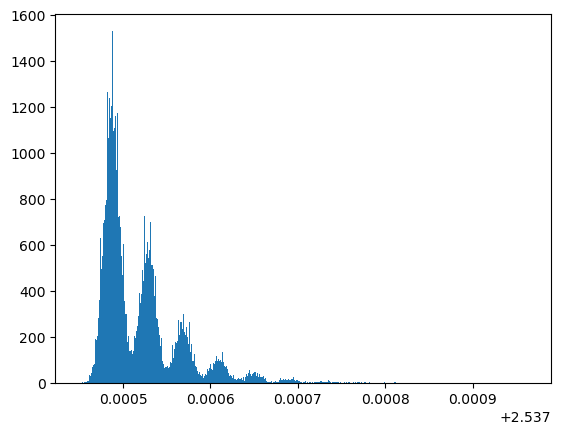

In [65]:
hist = plt.hist(results[:,0,0],bins=500)

## Load 

In [66]:
date_time = "2023-05-31-12-17"
path_save = f"NN Log/{date_time}/"

In [67]:
config_load = np.load(f"{path_save}log.npy",allow_pickle=True)
config_load

array({'path_data': 'Datasets/Guillaume Thekkadath/', 'path_save': 'NN Log/', 'layer_number': '7', 'layer_type': 'Linear', 'layer_conv': 'None', 'activation_type': 'ReLU', 'batch_size': 5000, 'optimizer': 'adam', 'epochs': 10, 'learning_rate': 0.001},
      dtype=object)

Text(0.5, 0, 'output value')

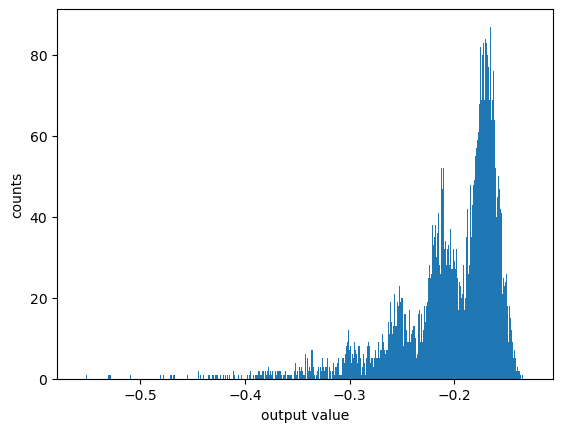

In [68]:
x = np.load(f"{path_save}results.npy",allow_pickle=True)
plot = plt.hist(x[:,0,0],bins=500)
plt.ylabel("counts")
plt.xlabel("output value")

Text(0.5, 0, 'epoch')

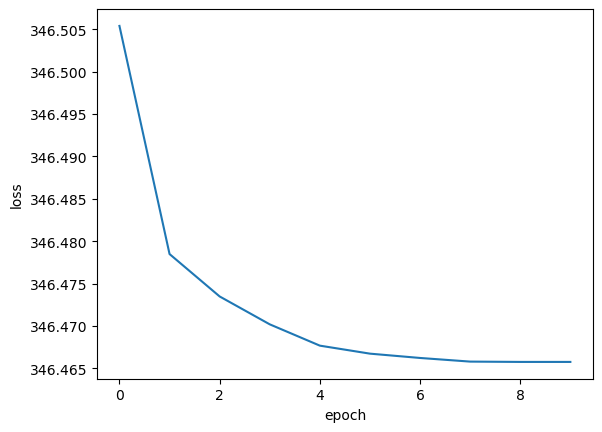

In [69]:
x = np.load(f"{path_save}epoch_loss.npy",allow_pickle=True)
plot = plt.plot(x)
plt.ylabel("loss")
plt.xlabel("epoch")

Text(0.5, 0, 'batch step')

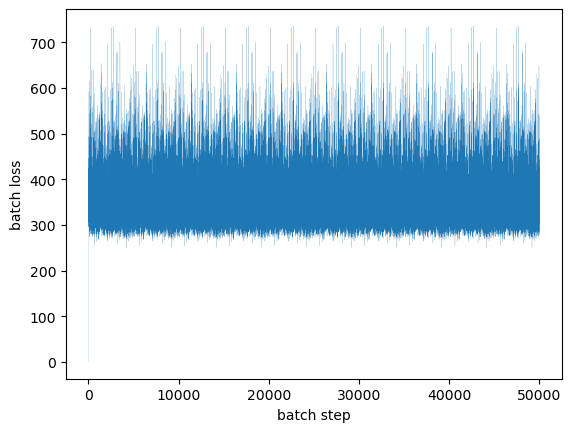

In [70]:
x = np.load(f"{path_save}batch_loss.npy",allow_pickle=True)
plot = plt.plot(x,linewidth=0.1)
plt.ylabel("batch loss")
plt.xlabel("batch step")